## Analisis Regresi Linear Sederhana

Kelompok:

1. Ihsan Maulana Prasetia
2. Maulana Shiddiq Afdhauddin

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Muat dataset
df = pd.read_csv('/content/Salary_dataset.csv')

# Tampilkan 5 baris pertama data
print("5 Baris Pertama Dataset:")
display(df.head())

5 Baris Pertama Dataset:


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


Dataset ini tampaknya berisi kolom 'YearsExperience' (Pengalaman Tahun) dan 'Salary' (Gaji). Kita akan menggunakan 'YearsExperience' sebagai variabel independen (X) dan 'Salary' sebagai variabel dependen (y) untuk membangun model regresi linear.

In [ ]:
# Definisikan variabel independen (X) dan dependen (y)
X = df[['YearsExperience']]
y = df['Salary']

# Bagi data menjadi set pelatihan dan pengujian
# Menggunakan 10 sampel untuk pelatihan dan sisanya untuk pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=10, random_state=42)

# Inisialisasi dan latih model regresi linear
model = LinearRegression()
model.fit(X_train, y_train)

# Buat prediksi pada set pengujian
y_pred = model.predict(X_test)

print("Model Regresi Linear Berhasil Dilatih.")
print(f"Koefisien (Slope): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"R-squared (pada data uji): {r2_score(y_test, y_pred):.2f}")
print(f"Mean Squared Error (pada data uji): {mean_squared_error(y_test, y_pred):.2f}")

Model Regresi Linear Berhasil Dilatih.
Koefisien (Slope): 9337.64
Intercept: 26975.79
R-squared (pada data uji): 0.95
Mean Squared Error (pada data uji): 38304295.76


### Interpretasi Koefisien Model

*   **Koefisien (Slope):** `9337.64`
    Ini berarti bahwa untuk setiap peningkatan satu tahun dalam `YearsExperience` (Pengalaman Kerja), `Salary` (Gaji) diprediksi akan meningkat sebesar `9337.64` unit (misalnya, USD 9337.64), dengan asumsi faktor lain tetap.
*   **Intercept:** `26975.79`
    Ini adalah nilai `Salary` yang diprediksi ketika `YearsExperience` adalah nol. Dalam konteks ini, ini bisa diinterpretasikan sebagai gaji dasar atau gaji awal yang diprediksi untuk seseorang tanpa pengalaman kerja. Namun, interpretasi intercept harus hati-hati, terutama jika nilai nol untuk variabel independen tidak realistis atau di luar jangkauan data yang diamati.

### Penilaian Performa Model

*   **R-squared (pada data uji):** `0.95`
    Nilai R-squared sebesar 0.95 (atau 95%) menunjukkan bahwa 95% variasi dalam `Salary` dapat dijelaskan oleh `YearsExperience`. Ini adalah nilai R-squared yang sangat tinggi, menunjukkan bahwa model memiliki kekuatan penjelasan yang sangat baik untuk data pengujian.
*   **Mean Squared Error (MSE) (pada data uji):** `38304295.76`
    MSE adalah rata-rata kuadrat dari error (perbedaan antara nilai aktual dan nilai prediksi). Nilai ini menunjukkan seberapa besar 'rata-rata' kesalahan prediksi model. Semakin kecil nilai MSE, semakin baik modelnya. Nilai ini perlu diinterpretasikan dalam skala gaji.

### Indikasi Overfitting atau Underfitting

Mengingat `R-squared` yang sangat tinggi (0.95) pada data uji, sekilas model tampak sangat baik. Namun, perlu diperhatikan bahwa model dilatih hanya dengan **10 sampel** (`train_size=10`) dari total 30 data. Jumlah data pelatihan yang sangat kecil ini **sangat berisiko menyebabkan underfitting** atau setidaknya, model mungkin tidak belajar pola yang sesungguhnya secara robust. Meskipun `R-squared` pada data uji terlihat bagus, ini mungkin kebetulan karena sedikitnya data pelatihan dan pengujian, atau memang data yang sangat linear. Untuk memastikan tidak ada overfitting atau underfitting, disarankan untuk menggunakan ukuran data pelatihan yang lebih besar dan membandingkan metrik performa antara set pelatihan dan set pengujian.

Sekarang, mari kita visualisasikan data dan garis regresi yang dihasilkan. Garis merah akan menunjukkan model regresi linear yang telah dilatih.

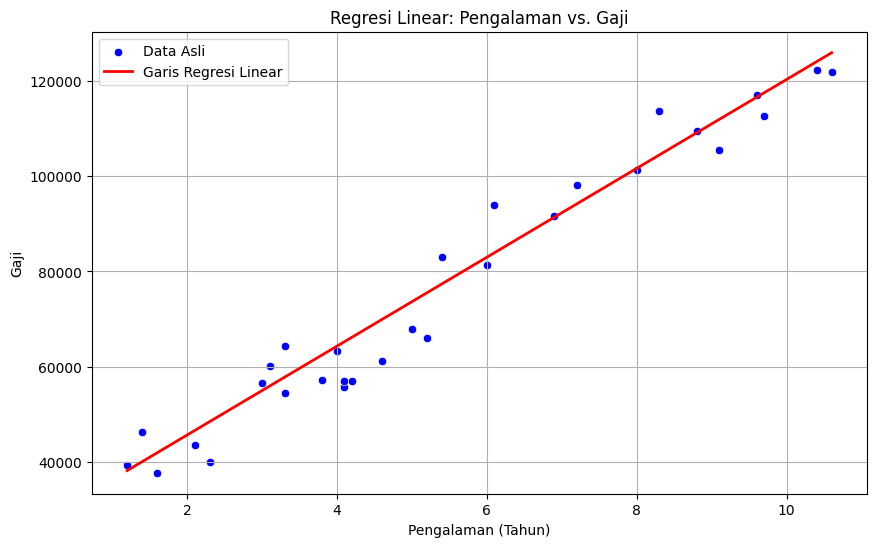

In [ ]:
# Buat plot sebar dari data asli
plt.figure(figsize=(10, 6))
sns.scatterplot(x='YearsExperience', y='Salary', data=df, color='blue', label='Data Asli')

# Plot garis regresi linear dari model yang dilatih
# Untuk garis regresi, gunakan rentang lengkap YearsExperience
plt.plot(X, model.predict(X), color='red', linestyle='-', linewidth=2, label='Garis Regresi Linear')

plt.title('Regresi Linear: Pengalaman vs. Gaji')
plt.xlabel('Pengalaman (Tahun)')
plt.ylabel('Gaji')
plt.legend()
plt.grid(True)
plt.show()


### Deskripsi Dataset

Dataset ini berisi 30 entri dengan 3 kolom:

*   **`Unnamed: 0`**: Kolom indeks yang tidak digunakan dan dapat diabaikan.
*   **`YearsExperience`**: Variabel independen yang merepresentasikan pengalaman kerja seseorang dalam tahun (tipe data float).
*   **`Salary`**: Variabel dependen yang merepresentasikan gaji seseorang (tipe data float).

Dataset ini menunjukkan hubungan antara pengalaman kerja dan gaji, yang akan dianalisis menggunakan regresi linear sederhana.

### Interpretasi Koefisien Model

*   **Koefisien (Slope):** `9337.64`
    Ini berarti bahwa untuk setiap peningkatan satu tahun dalam `YearsExperience` (Pengalaman Kerja), `Salary` (Gaji) diprediksi akan meningkat sebesar `9337.64` unit (misalnya, USD 9337.64), dengan asumsi faktor lain tetap.
*   **Intercept:** `26975.79`
    Ini adalah nilai `Salary` yang diprediksi ketika `YearsExperience` adalah nol. Dalam konteks ini, ini bisa diinterpretasikan sebagai gaji dasar atau gaji awal yang diprediksi untuk seseorang tanpa pengalaman kerja. Namun, interpretasi intercept harus hati-hati, terutama jika nilai nol untuk variabel independen tidak realistis atau di luar jangkauan data yang diamati.

### Penilaian Performa Model

*   **R-squared (pada data uji):** `0.95`
    Nilai R-squared sebesar 0.95 (atau 95%) menunjukkan bahwa 95% variasi dalam `Salary` dapat dijelaskan oleh `YearsExperience`. Ini adalah nilai R-squared yang sangat tinggi, menunjukkan bahwa model memiliki kekuatan penjelasan yang sangat baik untuk data pengujian.
*   **Mean Squared Error (MSE) (pada data uji):** `38304295.76`
    MSE adalah rata-rata kuadrat dari error (perbedaan antara nilai aktual dan nilai prediksi). Nilai ini menunjukkan seberapa besar 'rata-rata' kesalahan prediksi model. Semakin kecil nilai MSE, semakin baik modelnya. Nilai ini perlu diinterpretasikan dalam skala gaji.

### Indikasi Overfitting atau Underfitting

Mengingat `R-squared` yang sangat tinggi (0.95) pada data uji, sekilas model tampak sangat baik. Namun, perlu diperhatikan bahwa model dilatih hanya dengan **10 sampel** (`train_size=10`) dari total 30 data. Jumlah data pelatihan yang sangat kecil ini **sangat berisiko menyebabkan underfitting** atau setidaknya, model mungkin tidak belajar pola yang sesungguhnya secara robust. Meskipun `R-squared` pada data uji terlihat bagus, ini mungkin kebetulan karena sedikitnya data pelatihan dan pengujian, atau memang data yang sangat linear. Untuk memastikan tidak ada overfitting atau underfitting, disarankan untuk menggunakan ukuran data pelatihan yang lebih besar dan membandingkan metrik performa antara set pelatihan dan set pengujian.